In [2]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
# Load the loan dataset (working link)
url = "https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv"
df = pd.read_csv(url)

# Show first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
# Check shape and missing values
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (614, 13)

Missing values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [6]:
# Fill missing values
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Verify
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


C:\Users\Haseeb Najam\AppData\Local\Temp\ipykernel_20784\293691521.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='Set2')


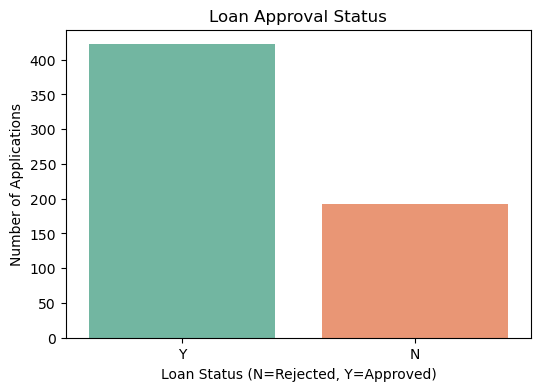

In [7]:
# Graph 1 - How many loans were approved vs rejected?
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df, palette='Set2')
plt.title('Loan Approval Status')
plt.xlabel('Loan Status (N=Rejected, Y=Approved)')
plt.ylabel('Number of Applications')
plt.show()

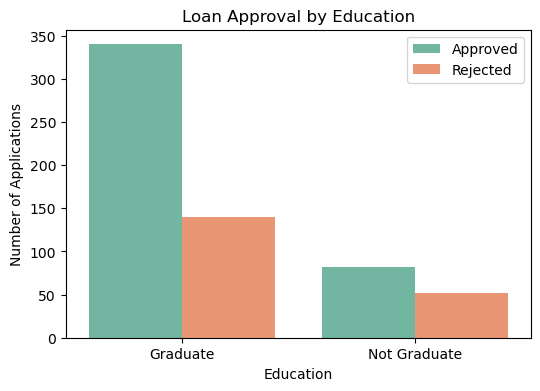

In [8]:
# Graph 2 - Does education affect loan approval?
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df, palette='Set2')
plt.title('Loan Approval by Education')
plt.xlabel('Education')
plt.ylabel('Number of Applications')
plt.legend(labels=['Approved', 'Rejected'])
plt.show()

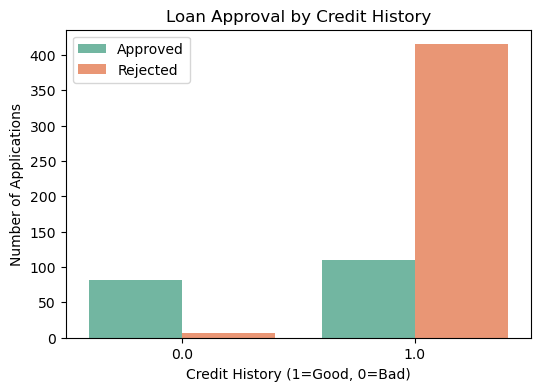

In [9]:
# Graph 3 - Does credit history affect loan approval?
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='Set2')
plt.title('Loan Approval by Credit History')
plt.xlabel('Credit History (1=Good, 0=Bad)')
plt.ylabel('Number of Applications')
plt.legend(labels=['Approved', 'Rejected'])
plt.show()

In [10]:
# Convert text columns to numbers
le = LabelEncoder()
columns = ['Gender', 'Married', 'Dependents', 
           'Education', 'Self_Employed', 
           'Property_Area', 'Loan_Status']

for col in columns:
    df[col] = le.fit_transform(df[col])

print("Text converted to numbers successfully!")
df.head()

Text converted to numbers successfully!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [11]:
# Select features and target
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, 
                                    test_size=0.2, 
                                    random_state=42)

# Build and train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 76.42%


C:\Users\Haseeb Najam\AppData\Local\Temp\ipykernel_20784\4057201054.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values,


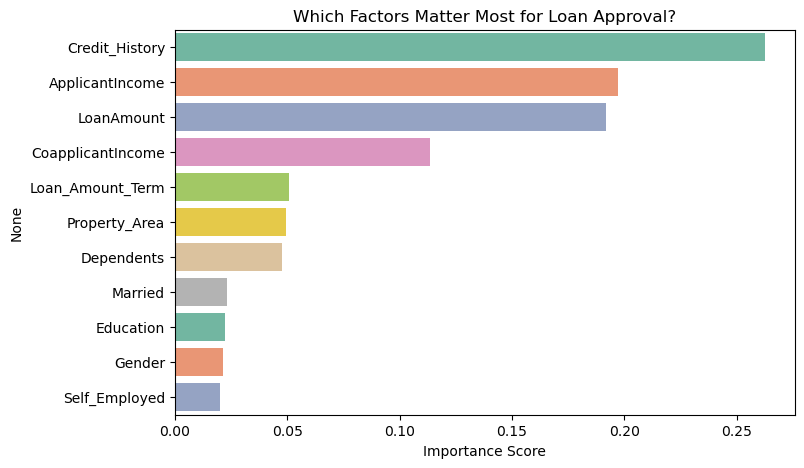

In [12]:
# Feature Importance Graph
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.values, 
            y=feature_importance.index, 
            palette='Set2')
plt.title('Which Factors Matter Most for Loan Approval?')
plt.xlabel('Importance Score')
plt.show()